## Emojify
Have you ever wanted to make your text messages more expressive? Your emojifier app will help you do that. So rather than writing "Congratulations on the promotion! Lets get coffee and talk. Love you!" the emojifier can automatically turn this into "Congratulations on the promotion! 👍 Lets get coffee and talk. ☕️ Love you! ❤️"

We will implement a model which inputs a sentence (such as "Let's go see the baseball game tonight!") and finds the most appropriate emoji to be used with this sentence (⚾️). In many emoji interfaces, you need to remember that ❤️ is the "heart" symbol rather than the "love" symbol. But using word vectors, you'll see that even if your training set explicitly relates only a few words to a particular emoji, your algorithm will be able to generalize and associate words in the test set to the same emoji even if those words don't even appear in the training set. This allows you to build an accurate classifier mapping from sentences to emojis, even using a small training set.

Here we start with a baseline model (Emojifier-V1) using the word embeddings, then build a more sophisticated model (Emojifier-V2) that further incorporates an LSTM.

Let get started.

In [1]:
import numpy as np
from emojify_utils import *
import matplotlib.pyplot as plt

%matplotlib inline


## Baseline model Emojifier-V1

## Dataset EMOJISET

Let start by building a simple baseline classifier.


We've dataset (X, Y) where:
* X contain 127 sentences (strings)
* Y contain a integer label between 0 and 4 corresponding to an emoji for each sentence.
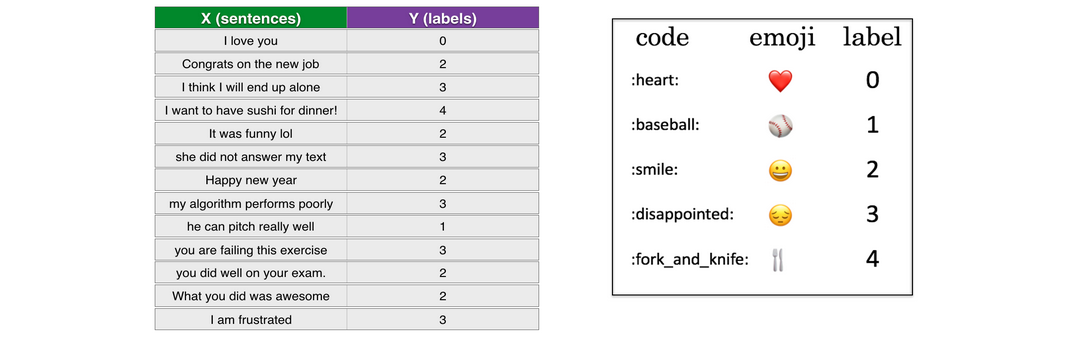

 **Figure 1**: EMOJISET - a classification problem with 5 classes. A few examples of sentences are given here.

 Let load the dataset using the code below, We split the dataset between training (127 examples) and testing (56 examples)



In [2]:
import pandas as pd
def read_csv(filename):

  df = pd.read_csv(filename, header=None)

  X = df[0].values
  Y = df[1].values
  return X, Y

In [3]:
X_train, Y_train = read_csv("data/train_emoji.csv")
X_test, Y_test = read_csv("data/test_emoji.csv")

In [4]:
maxLen = len(max(X_train, key=len).split())

Running the following code to print sentences from X_train and corresponding labels from Y_train . Change the `index` to see differnce. Because of the font the iPython notebook uses , the heart emoji may be colored black than red.


In [5]:
index = 1
print(X_train[index], label_to_emoji(Y_train[index]))

I am proud of your achievements 😄


## Overview of the Emojifier-V1
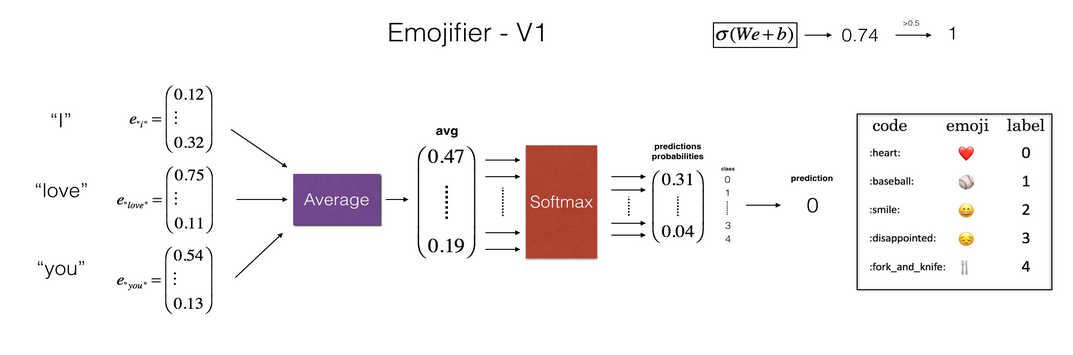

 **Figure 2**: Baseline model (Emojifier-V1).

 The input of the model is a string corresponding to a sentence (e.g. "I love you). In the code, the output will be a probability vector of shape (1,5), that you then pass in an argmax layer to extract the index of the most likely emoji output.

To get our labels into a format suitable for training a softmax classifier, lets convert Y from its current shape current shape into a "one-hot representation" (m, 5)  , where each row is a one-hot vector giving the label of one example, You can do so using this next code snipper. Here, `Y_oh` stands for `"Y-one-hot"` in the variable names `Y_oh_train` and `Y_oh_test`:


In [6]:
Y_oh_train = convert_to_one_hot(Y_train, C = 5)
Y_oh_test = convert_to_one_hot(Y_test, C= 5)

In [7]:
index = 50

print(Y_train[index], "is converted into one hot", Y_oh_train[index])

0 is converted into one hot [1. 0. 0. 0. 0.]


All the data is now ready to fed in to the Emojify-V1 model.Let's implement the model.

### Implementing the Emojifier-V1

As shown in Figure (2), the first step is to convert an input sentence into the word vector representation, which then get averaged together. Similar to the previous exercise, we will use pretrained 50-dimensional GloVe embeddings. Run the following cell to load the `word_to_vec_map`, which contains all the vector representations.



In [ ]:
word_to_index, index_to_word, word_to_vec_map = read_glove_vecs('data/glove.6B.50d.txt')

In [19]:
def build_vocab(sentences):
    vocab = set()
    for s in sentences:
        for w in s.lower().split():
            vocab.add(w)
    return vocab


In [20]:
def fake_glove(vocab, dim=50):
    word_to_vec_map = {}
    word_to_index = {}
    index_to_word = {}

    for i, word in enumerate(sorted(vocab), start=1):
        word_to_vec_map[word] = np.random.randn(dim) * 0.01
        word_to_index[word] = i
        index_to_word[i] = word

    return word_to_index, index_to_word, word_to_vec_map


In [21]:
vocab = build_vocab(X_train)
word_to_index, index_to_word, word_to_vec_map = fake_glove(vocab)




You've loaded:

    * word_to_index: dictionary mapping from words to their indices in the vocabulary (400,001 words, with the valid indices ranging from 0 to 400,000)
    * index_to_word: dictionary mapping from indices to their corresponding words in the vocabulary
    * word_to_vec_map: dictionary mapping words to their GloVe vector representation.

Run the following cell to check if it works.


In [22]:
word = "cucumber"
index = 289846
print("the index of", word, "in the vocabulary is", word_to_index[word])
print("the", str(index) + "th word in the vocabulary is", index_to_word[index])

KeyError: 'cucumber'

Now let implement the `sentence_to_average()` . We'll need to carry out 2 steps.
1. Convert every sentence to lower-case, then split the sentence into a list of words. `X.lower() and X.split()` might be useful.
2. For each word in the sentence, access its GloVe representation. Then, average all these values.

In [23]:
import numpy as np

def sentence_to_avg(sentence, word_to_vec_map):
    """
    Converts a sentence into the average of its word vectors.

    Arguments:
    sentence -- string
    word_to_vec_map -- dictionary mapping words to 50-dim vectors

    Returns:
    avg -- numpy array of shape (50,)
    """
    words = sentence.lower().split()

    avg = np.zeros((50,))
    count = 0

    for w in words:
        if w in word_to_vec_map:
            avg += word_to_vec_map[w]
            count += 1

    if count > 0:
        avg = avg / count

    return avg


In [24]:
avg = sentence_to_avg("Morrocan couscous is my favorite dish", word_to_vec_map)

print("avg = " , avg)

avg =  [-1.57471014e-03  9.63321626e-03 -5.03048433e-03  1.07224736e-02
  5.95527475e-03 -2.38724838e-03 -1.05675457e-03 -6.79240712e-03
  7.30356872e-03 -4.13478958e-03 -6.34353229e-04 -4.49681278e-03
  6.96143710e-03 -9.21349096e-03 -1.66029026e-03  1.16463695e-02
  9.42111496e-03 -2.93252002e-03  3.51639718e-03 -1.84925952e-03
 -6.14101057e-03 -7.56204448e-05 -7.88054311e-03  4.55298366e-03
  4.43486257e-04  6.61718242e-03  2.83261815e-03 -1.16086954e-03
 -2.12918991e-04 -1.79877051e-03  6.18367667e-03 -3.87498053e-03
  2.96454024e-03  5.32376351e-04  2.45484859e-03  3.06872385e-04
  2.63956917e-03 -1.61535647e-03  3.83072862e-03 -7.66338551e-03
  8.59555111e-03  1.53658901e-03 -6.79403279e-03 -4.69373956e-03
  1.24986307e-02 -7.23886112e-03 -7.86990842e-04  6.63968496e-03
 -1.12594577e-02  5.30052926e-04]


### Model

We now have all the pieces to finish implementing the model() function. After using sentence_to_avg() we need to pass the average through forward propagation, compute the cost, and then backpropagate to update the softmax's parameters.

Let implement the `model()` function described in Figure (2). Assuming here that $Y_oh$ `("Y one hot")` is the one-hot encoding of the output labels, the equations you need to implement in the forward pass and to compute the cross-entropy cost are:

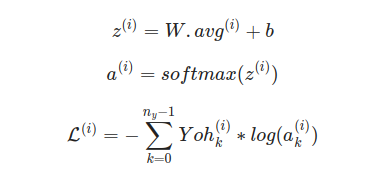


It is possible to come up with more efficient vectorized implementations. But since we're using the for-loop  to convert the sentence at a time to $avg^{(i)}$ representation anyway.

We go with a function that use `softmax()`

In [26]:
def softmax(z):
    """
    Compute softmax values for each class.

    Arguments:
    z -- numpy array of shape (n_y,)

    Returns:
    a -- softmax output, numpy array of shape (n_y,)
    """
    e_z = np.exp(z - np.max(z))   # for numerical stability
    return e_z / np.sum(e_z)


In [13]:
import numpy as np

def model(X, Y, word_to_vec_map, learning_rate=0.01, num_iterations=400):
    """
    Model to train word vector representations in numpy.

    Arguments:
    X -- input data, numpy array of sentences as strings, shape (m,)
    Y -- labels, numpy array of integers from 0 to 4, shape (m,)
    word_to_vec_map -- dictionary mapping words to 50-dim vectors
    learning_rate -- learning rate for SGD
    num_iterations -- number of training iterations

    Returns:
    pred -- predictions, numpy array of shape (m,)
    W -- weight matrix, shape (n_y, n_h)
    b -- bias vector, shape (n_y,)
    """
    np.random.seed(1)

    m = Y.shape[0]     # number of examples
    n_y = 5            # number of classes
    n_h = 50           # GloVe dimension

    # Xavier initialization
    W = np.random.randn(n_y, n_h) / np.sqrt(n_h)
    b = np.zeros((n_y,))

    # One-hot encoding
    Y_oh = convert_to_one_hot(Y, C=n_y)

    # Optimization loop
    for t in range(num_iterations):
        for i in range(m):

            # Sentence embedding (average of word vectors)
            avg = sentence_to_avg(X[i], word_to_vec_map)

            # Forward propagation
            z = np.dot(W, avg) + b
            a = softmax(z)

            # Cost
            cost = -np.sum(Y_oh[i] * np.log(a + 1e-8))

            # Backpropagation
            dz = a - Y_oh[i]
            dW = np.outer(dz, avg)
            db = dz

            # Update parameters
            W -= learning_rate * dW
            b -= learning_rate * db

        if t % 100 == 0:
            print(f"Epoch {t} --- cost = {cost:.4f}")

    pred = predict(X, Y, W, b, word_to_vec_map)
    return pred, W, b


In [14]:
print(X_train.shape)
print(Y_train.shape)
print(np.eye(5)[Y_train.reshape(-1)].shape)
print(X_train[0])
Y = np.asarray([5,0,0,5, 4, 4, 4, 6, 6, 4, 1, 1, 5, 6, 6, 3, 6, 3, 4, 4])
print(Y.shape)

X = np.asarray(['I am going to the bar tonight', 'I love you', 'miss you my dear',
 'Lets go party and drinks','Congrats on the new job','Congratulations',
 'I am so happy for you', 'Why are you feeling bad', 'What is wrong with you',
 'You totally deserve this prize', 'Let us go play football',
 'Are you down for football this afternoon', 'Work hard play harder',
 'It is suprising how people can be dumb sometimes',
 'I am very disappointed','It is the best day in my life',
 'I think I will end up alone','My life is so boring','Good job',
 'Great so awesome'])

print(X.shape)
print(np.eye(5)[Y_train.reshape(-1)].shape)
print(type(X_train))

(132,)
(132,)
(132, 5)
never talk to me again
(20,)
(20,)
(132, 5)
<class 'numpy.ndarray'>


In [36]:
def predict(X, Y, W, b, word_to_vec_map):
    m = X.shape[0]
    pred = np.zeros((m, 1))

    for i in range(m):
        avg = sentence_to_avg(X[i], word_to_vec_map)
        z = np.dot(W, avg) + b
        a = softmax(z)
        pred[i] = np.argmax(a)

    if Y is not None and Y.shape[0] == m:
        accuracy = np.mean(pred.reshape(-1) == Y.reshape(-1))
        print("Accuracy:", accuracy)

    return pred


In [37]:
pred, W, b = model(X_train, Y_train, word_to_vec_map)
print(pred)

Epoch 0 --- cost = 1.5301
Epoch 100 --- cost = 1.2655
Epoch 200 --- cost = 1.2605
Epoch 300 --- cost = 1.2554
Accuracy: 0.2878787878787879
[[2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]
 [2.]]


Our model has prety high accuracy on the training set. Lets see how it does on the test set.


### Examining test set performance


In [31]:
print("Training set:")
pred_train = predict(X_train, Y_train, W, b, word_to_vec_map)
print("Test set:")
pred_test = predict(X_test, Y_test, W, b, word_to_vec_map)

Training set:
Accuracy: 0.2878787878787879
Test set:
Accuracy: 0.32142857142857145


Random guessing would have had 20% accuracy given that there are 5 classes. This is pretty good performance after training on only 127 examples.

In the training set, the algorithm saw the sentence "I love you" with the label ❤️. You can check however that the word "adore" does not appear in the training set. Nonetheless, lets see what happens if you write "I adore you

In [33]:
def print_predictions(X, pred):
    """
    Prints sentences with their predicted emoji.

    Arguments:
    X -- input sentences, numpy array of shape (m, 1)
    pred -- predicted labels, numpy array of shape (m, 1)
    """

    m = X.shape[0]

    for i in range(m):
        print(X[i][0] + " " + label_to_emoji(int(pred[i])))


In [38]:
X_my_sentences = np.array(["i adore you", "i love you", "funny lol", "lets play with a ball", "food is ready", "not feeling happy"])
Y_my_labels = np.array([[0], [0], [2], [4], [3]])

pred = predict(X_my_sentences, Y_my_labels, W, b, word_to_vec_map)

print_predictions(X_my_sentences, pred)

i 😄
i 😄
f 😄
l 😄
f 😄
n 😄


/tmp/ipython-input-2901372390.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(X[i][0] + " " + label_to_emoji(int(pred[i])))




Amazing! Because adore has a similar embedding as love, the algorithm has generalized correctly even to a word it has never seen before. Words such as heart, dear, beloved or adore have embedding vectors similar to love, and so might work too---feel free to modify the inputs above and try out a variety of input sentences. How well does it work?

Note though that it doesn't get "not feeling happy" correct. This algorithm ignores word ordering, so is not good at understanding phrases like "not happy."

Printing the confusion matrix can also help understand which classes are more difficult for your model. A confusion matrix shows how often an example whose label is one class ("actual" class) is mislabeled by the algorithm with a different class ("predicted" class).



In [45]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, classes=None):
    """
    Plots a confusion matrix using matplotlib.

    Arguments:
    y_true  -- true labels, numpy array of shape (m,) or (m, 1)
    y_pred  -- predicted labels, numpy array of shape (m,) or (m, 1)
    classes -- list of class names/emojis (optional)
    """

    # Flatten inputs
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    # Infer classes if not provided
    if classes is None:
        classes = np.unique(y_true)

    n_classes = len(classes)

    # Initialize confusion matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)

    # Populate confusion matrix
    for true_label, pred_label in zip(y_true, y_pred):
        cm[int(true_label), int(pred_label)] += 1

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    plt.xticks(range(n_classes), classes)
    plt.yticks(range(n_classes), classes)

    # Add values inside cells
    threshold = cm.max() / 2
    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


(56,)
           ❤️    ⚾    😄    😞   🍴
Predicted  2.0  All
Actual             
0           12   12
1            5    5
2           18   18
3           15   15
4            6    6
All         56   56


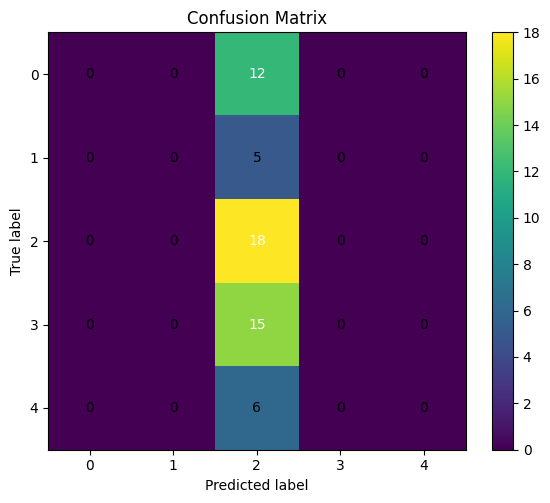

In [46]:
print(Y_test.shape)
print('           '+ label_to_emoji(0)+ '    ' + label_to_emoji(1) + '    ' +  label_to_emoji(2)+ '    ' + label_to_emoji(3)+'   ' + label_to_emoji(4))
print(pd.crosstab(Y_test, pred_test.reshape(56,), rownames=['Actual'], colnames=['Predicted'], margins=True))
plot_confusion_matrix(Y_test, pred_test)

**What you should remember from this part**: - Even with a 127 training examples, you can get a reasonably good model for Emojifying. This is due to the generalization power word vectors gives you. - Emojify-V1 will perform poorly on sentences such as *"This movie is not good and not enjoyable"* because it doesn't understand combinations of words--it just averages all the words' embedding vectors together, without paying attention to the ordering of words. We will build a better algorithm in the next part.

##  Emojifier-V2: Using LSTMs in Keras:



Let's build an LSTM model that takes as input word sequences. This model will be able to take word ordering into account. Emojifier-V2 will continue to use pre-trained word embeddings to represent words, but will feed them into an LSTM, whose job it is to predict the most appropriate emoji.

In [50]:
import numpy as np
np.random.seed(0)
from keras.models import Model
from keras.layers import Dense, Dropout, LSTM, Activation, Embedding
# from keras.layers.embeddings import Embedding
from keras.preprocessing import sequence
from keras.initializers import glorot_uniform
np.random.seed(1)

## Overview of the Model
Here is the Emojifier-v2 we will implement:
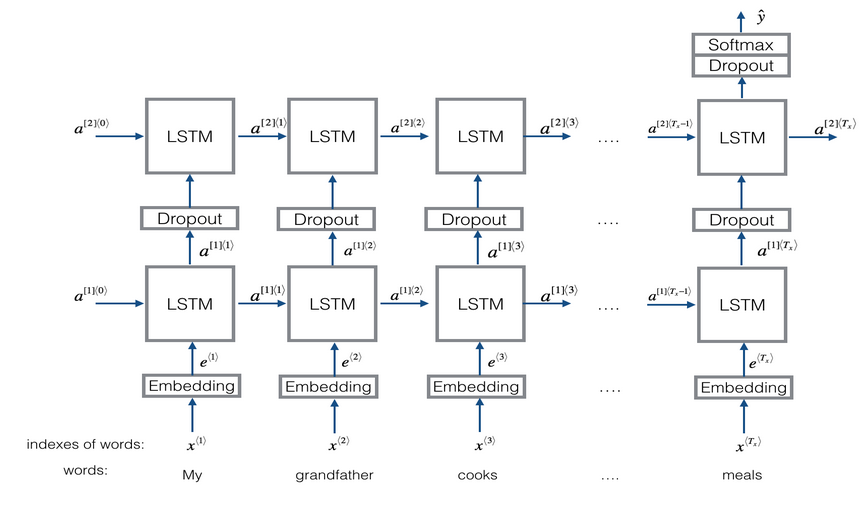

 **Figure 3**: Emojifier-V2. A 2-layer LSTM sequence classifier.

In this exercise, we want to train Keras using mini-batches. However, most deep learning frameworks require that all sequences in the same mini-batch have the same length. This is what allows vectorization to work: If you had a 3-word sentence and a 4-word sentence, then the computations needed for them are different (one takes 3 steps of an LSTM, one takes 4 steps) so it's just not possible to do them both at the same time.

The common solution to this is to use padding. Specifically, set a maximum sequence length, and pad all sequences to the same length. For example, of the maximum sequence length is 20, we could pad every sentence with "0"s so that each input sentence is of length 20. Thus, a sentence "i love you" would be represented as $(e_i, e_{\text{love}}, e_{\text{you}}, 0, 0, \ldots, 0)$

. In this example, any sentences longer than 20 words would have to be truncated. One simple way to choose the maximum sequence length is to just pick the length of the longest sentence in the training set.


## The Embedding Layer
In Keras, the embedding matrix is represented as a "layer", and maps positive integers (indices corresponding to words) into dense vectors of fixed size (the embedding vectors). It can be trained or initialized with a pretrained embedding. In this part, you will learn how to create an `Embedding()` layer in Keras, initialize it with the GloVe 50-dimensional vectors loaded earlier in the notebook. Because our training set is quite small, we will not update the word embeddings but will instead leave their values fixed. But in the code below, we'll show you how Keras allows you to either train or leave fixed this layer.

The `Embedding()` layer takes an integer matrix of size `(batch size, max input length)` as input. This corresponds to sentences converted into lists of indices (integers), as shown in the figure below.

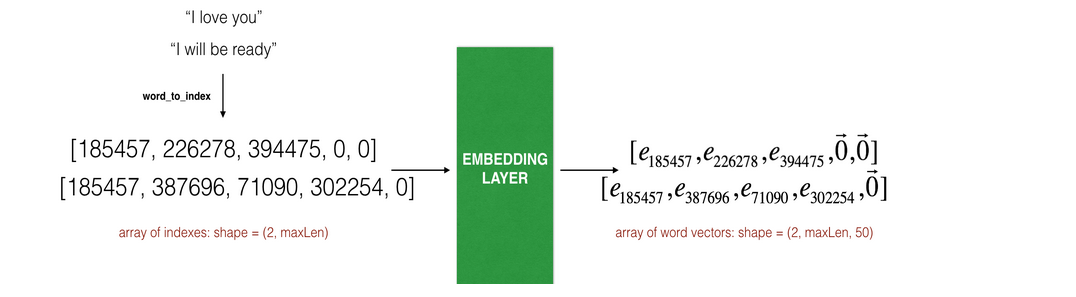

**Figure 4**: Embedding layer. This example shows the propagation of two examples through the embedding layer. Both have been zero-padded to a length of `max_len=5`. The final dimension of the representation is `(2,max_len,50)` because the word embeddings we are using are 50 dimensional.

The largest integer (i.e. word index) in the input should be no larger than the vocabulary size. The layer outputs an array of shape (batch size, max input length, dimension of word vectors).

The first step is to convert all your training sentences into lists of indices, and then zero-pad all these lists so that their length is the length of the longest sentence.

We implement the function below to convert `X` (array of sentences as strings) into an array of indices corresponding to words in the sentences. The output shape should be such that it can be given to `Embedding()` (described in Figure 4).

In [51]:
def sentence_to_indices(X, word_to_index, max_len):
  """
  Converts an array of sentences (strings) into an array of indices corresponding to words in the sentences.
  The output shape should be such that it can be given to `Embedding()` (described in Figure 4).

  Arguments:
  X -- array of sentences (strings), of shape (m, 1)
  word_to_index -- a dictionary containing the each word mapped to its index
  max_len -- maximum number of words in a sentence. You can assume every sentence in X is no longer than this.

  Returns:
  X_indices -- array of indices corresponding to words in the sentences from X, of shape (m, max_len)
  """

  m = X.shape[0]     # no:of training exmaples

  # Initialize X_indices as a numpy matrix of zeros and the correct shape.
  X_indices = np.zeors((m, max_len))

  for i in range(m):

    # Convert the ith training sentence in lower case and split is into words. You should get a list of words.
    sentence_words = X[i].lower().split()

    # Init: j to 0
    j = 0

    # Looping over the words of sentence_words

    for w in sentence_words:
      # set (i, j) the entry of the X_indcies to the index of the correct word.
      X_indices[i, j] = word_to_index[w]
      j = j + 1

  return X_indices






Run the following cell to check what sentences_to_indices() does, and check your results.


In [52]:
X1 = np.array(["funny lol", "lets play baseball", "food is ready for you"])
X1_indices = sentences_to_indices(X1,word_to_index, max_len = 5)
print("X1 = ", X1)
print("X1_indices =", X1_indices)

X1 =  ['funny lol' 'lets play baseball' 'food is ready for you']
X1_indices = [[ 91 146   0   0   0]
 [141 181  30   0   0]
 [ 84 131 192  85 258]]


Let's build the `Embedding()` layer in Keras, using pre-trained word vectors. After this layer is built, you will pass the output of `sentences_to_indices()` to it as an input, and the `Embedding()` layer will return the word embeddings for a sentence.

Implementing `pretrained_embedding_layer()`. We will need to carry out the following steps:
1. Initialize the embedding matrix as a numpy array of zeroes with the correct shape.
2. Fill in the embedding matrix with all the word embeddings extracted from `word_to_vec_map`.
3. Define Keras embedding layer. Use Embedding(). Be sure to make this layer non-trainable, by setting `trainable = False` when calling Embedding(). If you were to set `trainable = True`, then it will allow the optimization algorithm to modify the values of the word embeddings.
4. Set the embedding weights to be equal to the embedding matrix

In [53]:
def prettained_embedding_layer(word_to_vec_map, word_to_index):
  """
  Creates a Keras Embedding() layer and loads in pre-trained GloVe 50-dimensional vectors.

  Arguments:
  word_to_vec_map -- dictionary mapping words to their GloVe vector representation.
  word_to_index -- dictionary mapping from words to their indices in the vocabulary (400,001 words)

  Returns:
  embedding_layer -- pretrained layer Keras instance
  """

  vocab_len = len(word_to_index) + 1                  # adding 1 to fit Keras embedding (requirement)
  emb_dim = word_to_vec_map["cucumber"].shape[0]      # define dimensionality of your GloVe word vectors (= 50)

  # Initialize the embedding matrix as a numpy array of zeros of shape (vocab_len, dimensions of word vectors = emb_dim)
  emb_matrix = np.zeros((vocab_len, emb_dim))

  # Set each row "index" of the embedding matrix to be the word vector representation of the "index"th word of the vocabulary

  for word , index in word_to_index.items():
    emb_matrix[index, :] = word_to_vec_map[word]

  # Define Keras embedding layer with the correct output/input sizes, make it trainable. Use Embedding(...). Make sure to set trainable=False.
  embedding_layer = Embedding(vocab_len, emb_dim)

  # Build the embedding layer, it is required before setting the weights of the embedding layer. Do not modify the "None".
  embedding_layer.build((None, ))

  # Set the weights of the embedding layer to the embedding matrix. Your layer is now pretrained.
  embedding_layer.set_weights([emb_matrix])

  return embedding_layer










In [55]:
embedding_layer = pretrained_embedding_layer(word_to_vec_map, word_to_index)
print("weights[0][1][3] =", embedding_layer.get_weights()[0][1][3])

weights[0][1][3] = -0.010729686


## Building the Emojifier-V2

Lets now build the Emojifier-V2 model. You will do so using the embedding layer you have built, and feed its output to an LSTM network.

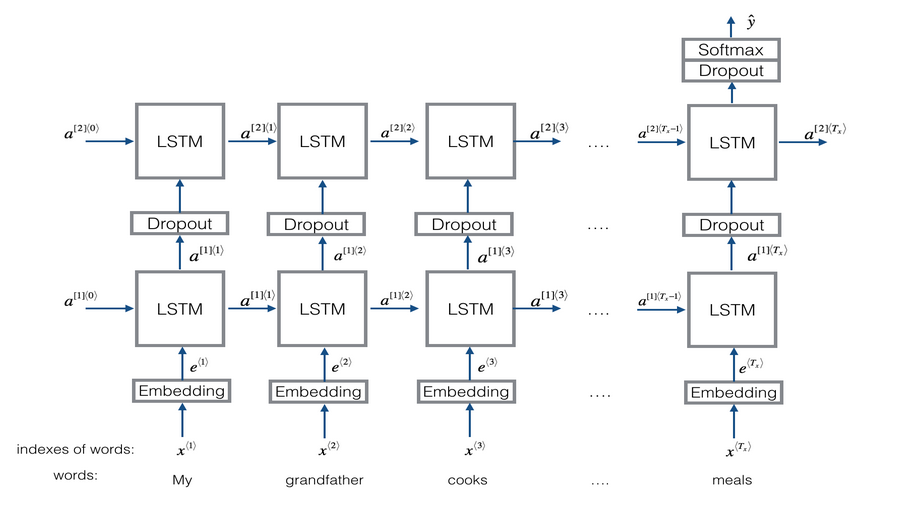

 **Figure 3**: Emojifier-v2. A 2-layer LSTM sequence classifier.

 Now let implement `Emojify_V2()`, which builds a Keras graph of the architecture shown in Figure 3. The model takes as input an array of sentences of shape `(m, max_len, )` defined by `input_shape`. It should output a softmax probability vector of shape `(m, C = 5)`. You may need `Input(shape = ..., dtype = '...'), LSTM(), Dropout(), Dense(), and Activation().`

In [56]:
def emojify_V2(input_shape, word_to_vec_map, word_to_index):
  """
  Function creating the Emojify-v2 model's graph.

  Arguments:
  input_shape -- shape of the input, usually (max_len,)
  word_to_vec_map -- dictionary mapping every word in a vocabulary into its 50-dimensional vector representation
  word_to_index -- dictionary mapping from words to their indices in the vocabulary (400,001 words)

  Returns:
  model -- a model instance in Keras
  """

  # Define sentence_indices as the input of the graph, it should be of shape input_shape and dtype 'int32' (as it contains indices).
  sentence_indices = Input(shape=input_shape, dtype=int.int32)

  # Create the embedding layer pretrained with GloVe Vectors.
  embedding_layer = pertrained_embedding_layer(word_to_vec_map, word_to_index)

  # Propagates the sentence_indices through the embedding layer, you get back the embeddings.
  embeddings = embedding_layer(sentence_indices)

  # Propagate the embeddings through an LSTM layer with 128-dimensional hidden state
  # Be careful the returned output should be a batch of sequences.

  X = LSTM(128, return_sequnces=True)(embeddings)
  # Adding dropout with a probability of 0.5
  X = Dropout(0.5)(X)
  # Propagate X trough another LSTM layer with 128-dimensional hidden state
  # Be careful, the returned output should be a single hidden state, not a batch of sequences.
  X = LSTM(128)(X)
  # Add dropout with a probability of 0.5
  X = Dropout(0.5)(X)
  # Propagate X through a Dense layer with softmax activation to get back a batch of 5-dimensional vectors.
  X = Dense(5, activation="softmax")(X)
  # Add a softmax activation
  X = Activation('softmax')(X)

  # Create a Model instance which converts sentece_indices into X
  model = Model(sentence_indices, X)

  return model












Run the following cell to create your model and check its summary. Because all sentences in the dataset are less than 10 words, we chose `max_len = 10. You should see your architecture, it uses "20,223,927" parameters, of which 20,000,050 (the word embeddings) are non-trainable, and the remaining 223,877 are. Because our vocabulary size has 400,001 words (with valid indices from 0 to 400,000) there are 400,001*50 = 20,000,050 non-trainable parameters.


In [57]:
model = Emojify_V2((maxLen,), word_to_vec_map, word_to_index)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 10, 50)         │        13,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 128)        │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,927 (925.50 KB)

 Trainable params: 223,877 (874.52 KB)

 Non-trainable params: 13,050 (50.98 KB)

As usual, after creating your model in Keras, you need to compile it and define what loss, optimizer and metrics your are want to use. Compile your model using categorical_crossentropy loss, adam optimizer and `['accuracy']` metrics:


In [60]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



It's time to train your model. Your Emojifier-V2 model takes as input an array of shape `(m, max_len)` and outputs probability vectors of shape `(m, number of classes)`. We thus have to convert X_train (array of sentences as strings) to X_train_indices (array of sentences as list of word indices), and Y_train (labels as indices) to Y_train_oh (labels as one-hot vectors).


In [61]:
X_train_indices = sentences_to_indices(X_train, word_to_index, maxLen)
Y_train_oh = convert_to_one_hot(Y_train, C = 5)



Fit the Keras model on `X_train_indices` and` Y_train_oh`. We will use `epochs = 50` and `batch_size = 32.`


In [62]:
model.fit(X_train_indices, Y_train_oh, epochs=50,batch_size = 32, shuffle=True)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.2469 - loss: 1.6078
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2652 - loss: 1.5951
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3126 - loss: 1.5700
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3141 - loss: 1.5462
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2215 - loss: 1.5383
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2695 - loss: 1.5646
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3006 - loss: 1.5657
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3349 - loss: 1.5469
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3336 - loss: 1.5626
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2723 - loss: 1.5568
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2937 - loss: 1.5409
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2792 - loss: 1.5379
E



The model should perform close to **100%** accuracy on the training set. The exact accuracy you get may be a little different. Run the following cell to evaluate your model on the test set.


In [63]:
X_test_indices = sentences_to_indices(X_test, word_to_index, max_len = maxLen)
Y_test_oh = convert_to_one_hot(Y_test, C = 5)
loss, acc = model.evaluate(X_test_indices, Y_test_oh)
print()
print("Test Accuracy = ", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2500 - loss: 1.6731 

Test Accuracy =  0.25




We should get a test accuracy between 80% and 95%. Run the cell below to see the mislabelled examples.


In [64]:
#This code allows to see the mislabeled examples

C = 5
y_test_on = np.eye(C)[Y_test.reshape(-1)]
X_test_indices = sentences_to_indices(X_test, word_to_index, maxLen)
pred = model.predict(X_test_indices)
for i in range(len(X_test)):
  x = X_test_indices
  num = np.argmax(pred[i])
  if (num  != Y_test[i]):
    print('Expected emoji:'+ label_to_emoji(Y_test[i]) + ' prediction: '+ X_test[i] + label_to_emoji(num).strip())


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step
Expected emoji:😞 prediction: he did not answer	😄
Expected emoji:❤️ prediction: she got me a present	😞
Expected emoji:❤️ prediction: he is a good friend	😄
Expected emoji:❤️ prediction: I am upset	😄
Expected emoji:❤️ prediction: We had such a lovely dinner tonight	⚾
Expected emoji:🍴 prediction: where is the food	😞
Expected emoji:⚾ prediction: where is the ball	😄
Expected emoji:😞 prediction: This girl is messing with me	😄
Expected emoji:😄 prediction: are you serious ha ha	😞
Expected emoji:⚾ prediction: Let us go play baseball	😄
Expected emoji:😞 prediction: This stupid grader is not working 	😄
Expected emoji:😄 prediction: Congratulation for having a baby	😞
Expected emoji:🍴 prediction: any suggestions for dinner	😞
Expected emoji:❤️ prediction: I love taking breaks	⚾
Expected emoji:😄 prediction: you brighten my day	😞
Expected emoji:🍴 prediction: I boiled rice	😞
Expected emoji:😞 prediction: she is a bully	😄
Expected emoji:😞 prediction: Why are you feelin



Now we can try it on your own example. Write your own sentence below.


In [65]:
# Change the sentence below to see your prediction. Make sure all the words are in the Glove embeddings.
x_test = np.array(["not feeling happy"])
X_test_indices = sentences_to_indices(x_test, word_to_index, maxLen)
print(x_test[0] +' ' + label_to_emoji(np.argmax(model.predict(X_test_indices))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
not feeling happy 😄




Previously, Emojify-V1 model did not correctly label "not feeling happy," but our implementation of Emojiy-V2 got it right. (Keras' outputs are slightly random each time, so you may not have obtained the same result.) The current model still isn't very robust at understanding negation (like "not happy") because the training set is small and so doesn't have a lot of examples of negation. But if the training set were larger, the LSTM model would be much better than the Emojify-V1 model at understanding such complex sentences.


 **What you should remember**: - If you have an NLP task where the training set is small, using word embeddings can help your algorithm significantly. Word embeddings allow your model to work on words in the test set that may not even have appeared in your training set. - Training sequence models in Keras (and in most other deep learning frameworks) requires a few important details: - To use mini-batches, the sequences need to be padded so that all the examples in a mini-batch have the same length. - An `Embedding()` layer can be initialized with pretrained values. These values can be either fixed or trained further on your dataset. If however your labeled dataset is small, it's usually not worth trying to train a large pre-trained set of embeddings. - `LSTM()` has a flag called `return_sequences` to decide if you would like to return every hidden states or only the last one. - You can use `Dropout()` right after `LSTM()` to regularize your network.